# Low-Volatility Anomaly — does boring really beat exciting? 🐌
### Racing the calm S&P 500 fund (SPLV) against the wild one (SPHB), in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Boring_beats_exciting%2C_risk--adjusted%3F: Confirmed](https://img.shields.io/badge/Boring_beats_exciting%2C_risk--adjusted%3F-Confirmed-8b949e?style=flat-square)

One of finance's most famous 'free lunches': **calm stocks quietly beat exciting ones** once you account for risk. You can buy each side off the shelf — Invesco sells an S&P 500 **Low Volatility** fund (SPLV) and an S&P 500 **High Beta** fund (SPHB), the 100 calmest and the 100 wildest names in the same index. So we race them. Does boring win? And if it does, can you make money betting on it?

> 📓 **This is the plain-language layer.** Want the *t*-stats, the bootstrap CI and the cost maths? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from low_volatility_anomaly import data, strategy as st

def load_real():
    """Cache-first real tape (empty frame offline). Drops the partial last month."""
    df = data.fetch_pairs(fetch=False)
    if df.empty:
        return df
    return data.drop_partial_last(df).dropna()

REAL = load_real()
HAVE_REAL = not REAL.empty
print("real SPLV/SPHB cache present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(REAL)} months, {REAL.index[0].date()} -> {REAL.index[-1].date()})")


real SPLV/SPHB cache present: True (180 months, 2011-06-30 -> 2026-05-31)


## The answer first 🎯

| Question | Answer |
|---|---|
| Does boring beat exciting *risk-adjusted*? | **Yes.** The calm fund (SPLV) earned a Sharpe of **0.85** vs the wild fund's (SPHB) **0.66** — on **less than half** the volatility (11.7% vs 24.8%). |
| So can I make money on it? | **Not easily.** The obvious trade — buy calm, short wild — *lost* **-6%/yr**: you'd be shorting the decade's biggest winner. |
| What if I hedge that out? | A risk-balanced version earns **+3.5%/yr**, but it's so thin the data can't tell it from luck (*t* = 1.43). After costs it's ~+2.5%/yr. |
| So what *is* it? | A real, useful **defensive tilt** — a calmer ride for a comparable Sharpe — not a self-financing money machine. |

> Boring genuinely *is* the better risk-adjusted hold. But 'better risk-adjusted' and 'a trade you can get paid for' are two different things — and that gap is the whole study.

## 1 · The claim

> *"Low-volatility stocks have delivered higher risk-adjusted returns than high-volatility stocks. Boring is beautiful."* — the low-volatility anomaly (Baker, Bradley & Wurgler 2011; Frazzini & Pedersen 2014).

The intuition: lots of investors can't (or won't) use leverage, so to chase big returns they crowd into **exciting, high-beta** stocks — overpaying for them. That leaves the **calm** stocks cheap, so they quietly out-earn per unit of risk. If true, the easiest free lunch in markets is simply *owning the boring ones*.

## 2 · So what?

This one matters because it's *backwards* from the first thing everyone learns: more risk should mean more reward. If the calm stocks actually win risk-adjusted, the textbook risk-return line is broken — and there's a fund you can buy to harvest it. The desk has already looked at the academic version on single stocks ([18 Dull-Roar](../../18-dull-roar/)) and at one calm fund vs the market ([58 Bunker](../../58-bunker/)). Here we do the cleanest head-to-head there is: the calmest fund against the wildest fund, same index, same shelf.

## 3 · How would we even know?

Three honest checks:

1. **Race the two funds.** SPLV vs SPHB on return, *and on Sharpe* (return per unit of risk). Boring can only 'win' the way the claim means it if it wins on **Sharpe**.
2. **Try to trade it.** Build the obvious bet — long the calm fund, short the wild one — and see whether it actually makes money.
3. **Be fair about risk.** The wild fund carries way more market exposure, so a naive short of it is really a short of *the market going up*. We hedge that out to isolate the real low-vol edge, then charge it honest costs and a borrow fee for the short.

Tape: monthly returns of SPLV, SPHB and SPY since both funds launched (2011).

## 4 · The teardown — let's actually look

**First: who's the better *risk-adjusted* hold?** Raw return vs Sharpe, the two funds side by side:

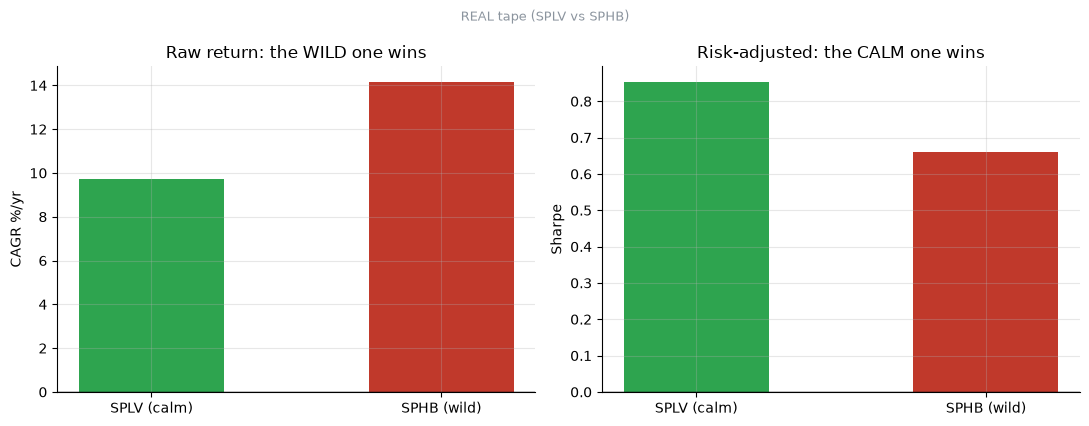

SPLV vol 11.7%  vs  SPHB vol 24.8%  ->  calm fund Sharpe 0.85 > wild 0.66


In [2]:
if HAVE_REAL:
    s_lo = st.leg_stats(REAL['SPLV']); s_hi = st.leg_stats(REAL['SPHB'])
    lo_cagr, lo_sh, lo_vol = s_lo['cagr']*100, s_lo['sharpe'], s_lo['vol']*100
    hi_cagr, hi_sh, hi_vol = s_hi['cagr']*100, s_hi['sharpe'], s_hi['vol']*100
    banner = 'REAL tape (SPLV vs SPHB)'
else:
    lo_cagr, lo_sh, lo_vol = 9.7, 0.85, 11.7
    hi_cagr, hi_sh, hi_vol = 14.2, 0.66, 24.8
    banner = 'SYNTHETIC fallback (frozen real numbers shown)'
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar(['SPLV (calm)','SPHB (wild)'], [lo_cagr, hi_cagr], color=[GREEN, RED], width=.5)
a1.set_ylabel('CAGR %/yr'); a1.set_title('Raw return: the WILD one wins')
a2.bar(['SPLV (calm)','SPHB (wild)'], [lo_sh, hi_sh], color=[GREEN, RED], width=.5)
a2.set_ylabel('Sharpe'); a2.set_title('Risk-adjusted: the CALM one wins')
for ax in (a1,a2): ax.axhline(0,c='k',lw=1)
fig.suptitle(banner, fontsize=9, color=GREY); plt.tight_layout(); plt.show()
print(f'SPLV vol {lo_vol:.1f}%  vs  SPHB vol {hi_vol:.1f}%  ->  calm fund Sharpe {lo_sh:.2f} > wild {hi_sh:.2f}')

There's the anomaly's signature. The wild fund made more raw return (+14% vs +10%/yr) — but it took **25% volatility to do it, versus 12% for the calm fund.** Per unit of risk, **boring wins**: Sharpe 0.85 vs 0.66. The calmer ride was the smarter ride.

**Now the trap. The obvious way to bet on this is to buy the calm fund and short the wild one.** What happens?

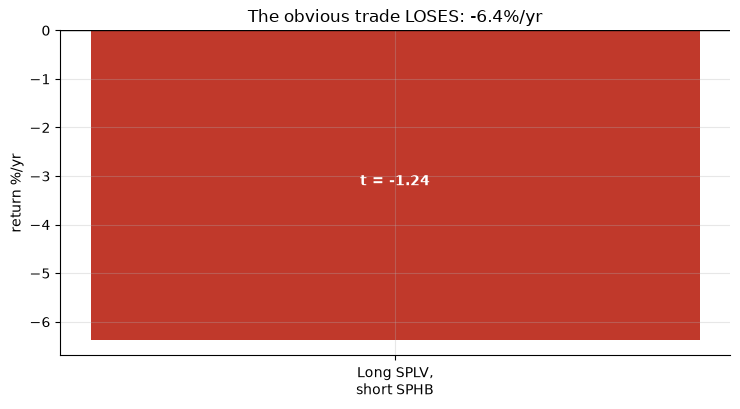

Buy calm / short wild: -6.4%/yr  (HAC t -1.24) -- a loser.


In [3]:
if HAVE_REAL:
    raw = st.spread_stats(st.spread(REAL)); raw_m, raw_t = raw['mean_ann']*100, raw['tstat']
else:
    raw_m, raw_t = -6.4, -1.24
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(['Long SPLV,\nshort SPHB'], [raw_m], color=RED, width=.4)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('return %/yr')
ax.set_title(f'The obvious trade LOSES: {raw_m:+.1f}%/yr')
ax.annotate(f't = {raw_t:+.2f}', (0, raw_m/2), ha='center', color='white', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Buy calm / short wild: {raw_m:+.1f}%/yr  (HAC t {raw_t:+.2f}) -- a loser.')

It **loses -6%/yr.** Why? Shorting the high-beta fund means shorting the part of the market that screamed higher all decade. You were *right* that the calm fund is the better risk-adjusted hold, and you still **lost money** making the obvious bet — because the bet was secretly 'the market will fall', and it didn't.

**So we hedge out that market bet** — short just enough of the wild fund to cancel the extra market exposure, leaving only the pure low-vol edge:

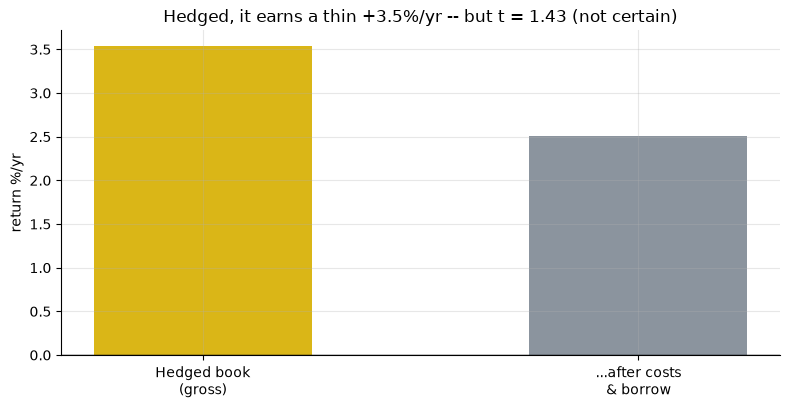

Beta-neutral: +3.5%/yr (t 1.43); after costs ~+2.5%/yr.


In [4]:
if HAVE_REAL:
    bn = st.spread_stats(st.beta_neutral_spread(REAL)); bn_m, bn_t = bn['mean_ann']*100, bn['tstat']
    bn_net = st.spread_stats(st.beta_neutral_spread(REAL, cost_bps=5.0, borrow_ann_bps=50.0))['mean_ann']*100
else:
    bn_m, bn_t, bn_net = 3.5, 1.43, 2.5
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.bar(['Hedged book\n(gross)','...after costs\n& borrow'], [bn_m, bn_net],
       color=[AMBER, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('return %/yr')
ax.set_title(f'Hedged, it earns a thin +{bn_m:.1f}%/yr -- but t = {bn_t:.2f} (not certain)')
plt.tight_layout(); plt.show()
print(f'Beta-neutral: +{bn_m:.1f}%/yr (t {bn_t:.2f}); after costs ~+{bn_net:.1f}%/yr.')

Hedged, it does earn a positive **+3.5%/yr** — but it's *so thin* the data can't distinguish it from luck (*t* = 1.43, below the desk's bar of 2). After realistic costs and a borrow fee for the short, it's ~+2.5%/yr. A whisper, not a free lunch.

## 5 · The verdict

- **Boring beats exciting risk-adjusted — Confirmed.** SPLV Sharpe 0.85 vs SPHB 0.66, on under half the volatility. The calm fund really is the better risk-adjusted hold.
- **Signal — Weak.** The *ranking* is right, but the *tradable* version earns only +3.5%/yr at *t* = 1.43 — this 15-year bull sample can't certify it.
- **Tradability — Fragile.** The naive trade loses -6%/yr; the hedged one is too thin to survive costs convincingly. What's real is a long-only defensive tilt, not a money machine.

## 6 · Could you actually trade it?

The honest use isn't the long-short at all — it's just **holding the calm fund**. You give up some raw upside in roaring bull years and get a much smoother ride (drawdown -21% vs the wild fund's -37%) for a comparable or better Sharpe. The long-short that would 'monetise the anomaly' is the part that doesn't survive: it either fights the market's beta or shrinks to a rounding error once you pay to run it. Boring is a good *hold*; it is not, on this sample, a good *trade*.

## 7 · Going further 🚪

- **The academic version.** [18 Dull-Roar](../../18-dull-roar/) runs the same idea on the S&P 500 *cross-section* (decile sorts) — and finds the modern large-cap sample actually *inverts* it. Same lesson, sharper.
- **Calm vs the market.** [58 Bunker](../../58-bunker/) races the min-vol fund (USMV) against SPY — and finds the same 'great defense, no free Sharpe' story.
- **A full cycle.** Both funds launched in 2011, so this sample missed 2008. Low-vol earns its keep in *bear* markets — fork this with a longer (or bear-heavy) window and see if the hedged edge clears the bar.

*Think boring should pay as a trade, not just a hold? Fork this, add a bear-market window or a vol-target overlay, and show the hedged spread clearing t = 2.*